<a href="https://colab.research.google.com/github/kevinquiosc-rgb/Projectos_Kevin/blob/main/NBEATS_PROYECTO_DATA_SCIENCE_TESINA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TESINA "Arquitectura de aprendizaje profundo N-BEATS para el pronóstico de Exportaciones de Perú, 2007 - 2021"

Durante el desarrollo de mi tesina enfocada a la proyección de series temporales, decidí iniciar una investigación de un algoritmo de estado del arte para este tipo de casuísticas y en mi revisión encontré un prometedor algoritmo con buenos resultados en plataformas como kaggle por lo que decidi aplicarlo en un problema real el pronostico de Productos Tradicionales.

Para más detalles sobre el modelo, véase: https://arxiv.org/pdf/1905.10437.pdf.



Los datos consistieron en el total de exportaciones (FOB) de 3 comodities de exportacion en Perú (Café, Harina de pescado y Cobre) extraidos de los boletines del INEI desde el 2007 hasta el 2019 y
de los muchos paquetes que incluyen el algoritmo N-BEATS utilice pytorch por su aplicación directa y en este notebook se mostrará la aplicacion directa al pronostico de CAFE

In [ ]:
# INSTALAR pytorch-forecast
!pip3 install pytorch-forecasting

Ademas complemente con librerias clasicas de procesado para series temporales.

In [ ]:
#IMPORTAR LIBRERIAS
from sklearn import preprocessing
import pandas as pd
import numpy as np
import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping
import torch
warnings.filterwarnings("ignore")
from pytorch_forecasting import Baseline, NBeats, TimeSeriesDataSet
from pytorch_forecasting.data import NaNLabelEncoder
from pytorch_forecasting.metrics import SMAPE
from pytorch_forecasting.metrics import RMSE
from pytorch_forecasting.metrics import MAPE

Se tomaron 180 registros por variable, esta esa distribuida de forma mensual y va del 2007 hasta el 2021.

In [ ]:
#vista de df
data.info()

In [ ]:
#vista de cabeceras
data.head()

In [ ]:
#añadir index y nombres del df para uso de pytorch
data['time_idx'] = np.arange(data.shape[0])
data['series'] = 0
data['value'] = data['FOB CAFE']
data['static'] = 2

In [ ]:
#int a float IMPORTANTE!!
data['value'] = data['value'].astype(float)

In [ ]:
#validar de int a float
data.info()

In [ ]:
#validar df
data.head()

Analisis grafoc de la serie temporal de CAFE en SPSS

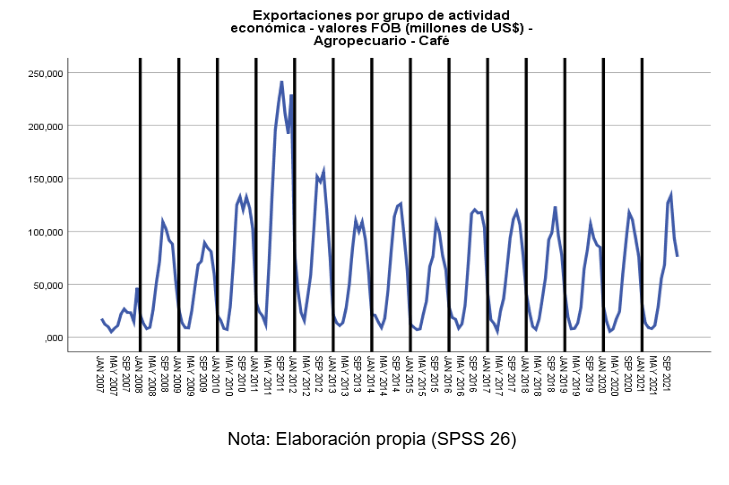

La serie muestra sin lugar a dudas un comportamiento estacional aproximadamente durante el 2do semestre de forma anual y constante, a excepción del inicio de la serie año 2007 y 2011 no se evidencia un comportamiento atípico en la serie.

Se evaluó normalidad, tendencia y valores atipicos aunque la arquitectura N-BEATS no depende de supuestos estadisticos a demas de no verse influenciado por valores atipicos.

Se inicia el seteo del modelo con sus hiperparametros

In [ ]:
# Definiendo ventana retrospectiva y de pronostico
max_encoder_length = 96 # Ventana retrospectiva W periodos necesarios para pronosticar
max_prediction_length = 36 # Horizonte de Pronostico H Periodos a pronosticar

training_cutoff = data["time_idx"].max() - max_prediction_length

context_length = max_encoder_length
prediction_length = max_prediction_length

training = TimeSeriesDataSet(
    data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="value",
    categorical_encoders={"series": NaNLabelEncoder(add_nan=True).fit(data.series)},
    group_ids=["series"],
    time_varying_unknown_reals=["value"],
    max_encoder_length=context_length,
    max_prediction_length=prediction_length,
)

validation = TimeSeriesDataSet.from_dataset(training, data, min_prediction_idx=training_cutoff + 1)
batch_size = 500
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

In [ ]:
# encontrar la mejor tasa de aprendizaje - learning rate
res = trainer.tuner.lr_find(net, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader, min_lr=1e-5)
print(f"suggested learning rate: {res.suggestion()}")
fig = res.plot(show=True, suggest=True)
fig.show()
net.hparams.learning_rate = res.suggestion()

Una tasa de aprendizaje debe mantener un equilibrio en orden que el modelo pueda aprender sin tener un sobreajuste o un ajuste demasiado lejano a los datos.

In [ ]:
# Ajustar el modelo
early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min")
trainer = pl.Trainer(
    max_epochs=500,
    gpus=0,
    enable_model_summary=True,
    gradient_clip_val=0.01,
    callbacks=[early_stop_callback],
    limit_train_batches=30,
)


net = NBeats.from_dataset(
    training,
    stack_types = ["generic"],
    num_blocks = [2],
    num_block_layers = [4],
    learning_rate= 0.022387211385683406,
    log_interval=10,
    log_val_interval=1,
    weight_decay=1e-2,
    widths=[512],
    backcast_loss_ratio=1.0,
)

trainer.fit(
    net,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

In [ ]:
#Guardando el mejor modelo encontrado
best_model_path = trainer.checkpoint_callback.best_model_path
best_model = NBeats.load_from_checkpoint(best_model_path)

In [ ]:
#real vs pronosticado
actuals = torch.cat([y[0] for x, y in iter(val_dataloader)])
predictions = best_model.predict(val_dataloader)
(actuals - predictions).abs().mean()

In [ ]:
#modelo
raw_predictions, x = best_model.predict(val_dataloader, mode="raw", return_x=True)

In [ ]:
#ploteo
for idx in range(1):  # si fueran mas series colocar >1
    best_model.plot_prediction(x, raw_predictions, idx=idx, add_loss_to_title=True);

In [ ]:
#ploteo
for idx in range(1):  # plot
    best_model.plot_interpretation(x, raw_predictions, idx=idx);

In [ ]:
#Calculando RMSE
import torch.nn as nn
criterion = nn.MSELoss()
torch.sqrt(criterion(actuals,predictions))

In [ ]:
#Calculando MAPE
((actuals - predictions).abs() / actuals.abs()).mean()

In [ ]:
best_model

In [ ]:
#guardando modelo a drive
model_save_name = 'cafeG.pt'
path = F"/content/drive/MyDrive/TESIS/{model_save_name}"
torch.save(best_model.state_dict(), path)

In [ ]:
#ABRIENDO MODELO DE DRIVE
model_save_name = 'cafeG.pt'
path = F"/content/drive/MyDrive/TESIS/{model_save_name}"
best_model.load_state_dict(torch.load(path))

De esta manera se aplico un algoritmo de estado del arte de series temporales, el modelo guardado para el pronostico de las exportaciones de cafe con un ajuste bastante aceptable del 91%